In [25]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings("ignore")
print('Libraries loaded ✓')

Libraries loaded ✓


In [26]:
# load dataset
df = pd.read_csv("../data/processed_data/bank-additional-engineered.csv")
df.head(1)

,job,marital,education,housing,loan,month,day_of_week,campaign,previous,cons.price.idx,cons.conf.idx,y,was_contacted_before,economic_index,is_risk,poutcome_success,is_cellular,age_group
0,housemaid,married,basic.4y,no,no,may,mon,1,0,93.994,-36.4,no,0,0.979435,0,0,0,working_age


In [27]:
df.shape

(41176, 18)

In [28]:
# Split features and target
X = df.drop(columns=['y'])
y = df['y'].map({'yes': 1, 'no': 0})

In [29]:
# Stratified Train-Test Split (Prevents data leakage during scaling/encoding)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41176 entries, 0 to 41175
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   job                   41176 non-null  object 
 1   marital               41176 non-null  object 
 2   education             41176 non-null  object 
 3   housing               41176 non-null  object 
 4   loan                  41176 non-null  object 
 5   month                 41176 non-null  object 
 6   day_of_week           41176 non-null  object 
 7   campaign              41176 non-null  int64  
 8   previous              41176 non-null  int64  
 9   cons.price.idx        41176 non-null  float64
 10  cons.conf.idx         41176 non-null  float64
 11  y                     41176 non-null  object 
 12  was_contacted_before  41176 non-null  int64  
 13  economic_index        41176 non-null  float64
 14  is_risk               41176 non-null  int64  
 15  poutcome_success   

In [31]:
cat_cols = df.select_dtypes(include=['object','category']).columns.drop('y')

In [32]:
print(cat_cols)

Index(['job', 'marital', 'education', 'housing', 'loan', 'month',
       'day_of_week', 'age_group'],
      dtype='object')


In [33]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

In [34]:
print(num_cols)

Index(['campaign', 'previous', 'cons.price.idx', 'cons.conf.idx',
       'was_contacted_before', 'economic_index', 'is_risk', 'poutcome_success',
       'is_cellular'],
      dtype='object')


In [35]:
# Assemble Transformer Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder='passthrough'  # Preserves engineered binary columns untouched
)

In [36]:
# Process Data matrices
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

In [37]:
# Capture dynamic feature names for explainability (SHAP)
feature_names = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_proc, columns=feature_names)
X_test_df = pd.DataFrame(X_test_proc, columns=feature_names)

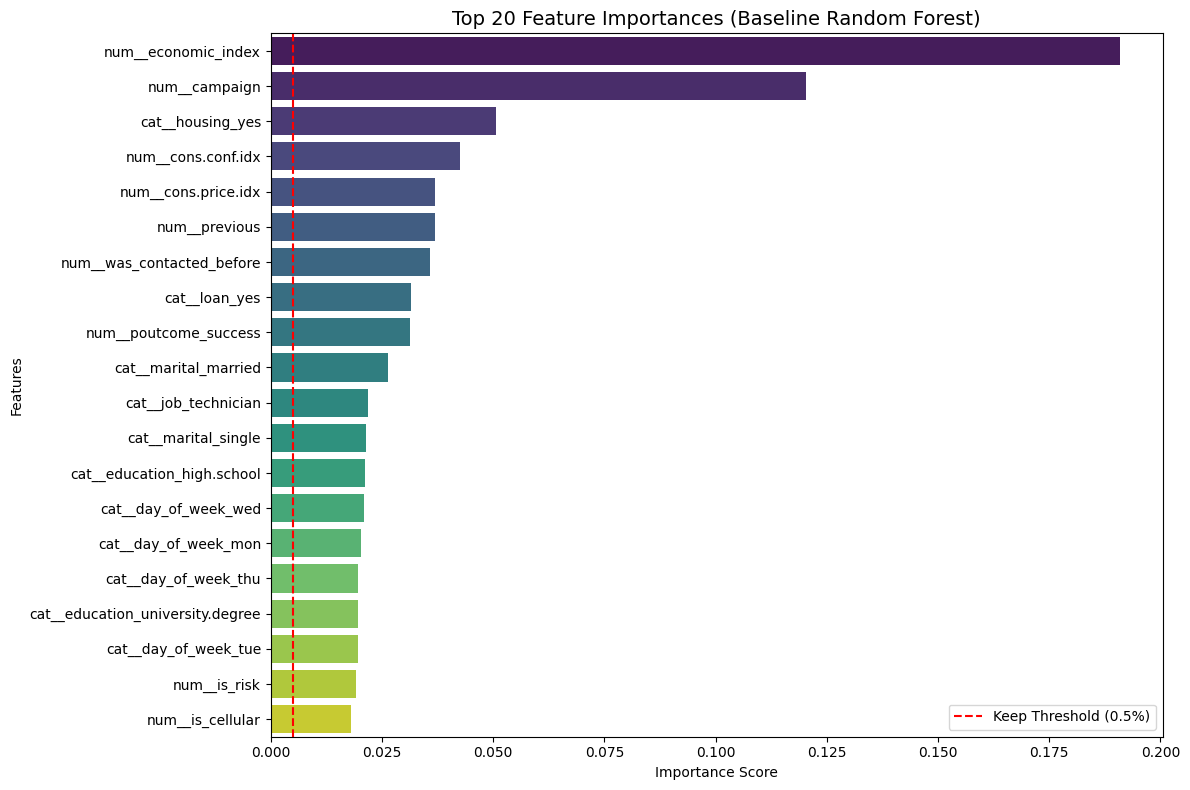

In [43]:
# Feature Selection / Dimensionality Reduction
selector_rf = RandomForestClassifier(random_state=42, n_jobs=-1)
selector_rf.fit(X_train_proc, y_train)

# Calculate threshold boundaries (Keep features contributing above 0.5% total split variance)
importances = selector_rf.feature_importances_
important_indices = [i for i, imp in enumerate(importances) if imp > 0.005]

# Create a DataFrame of your features and their importances
feat_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plotting the top features
plt.figure(figsize=(12, 8))
# Let's plot the top 20 features so the chart isn't overcrowded
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feat_importances.head(20), 
    palette='viridis',
    hue='Feature',
    legend=False
)
plt.title('Top 20 Feature Importances (Baseline Random Forest)', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.axvline(x=0.005, color='red', linestyle='--', label='Keep Threshold (0.5%)')
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
# Handle class Imbalance
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_selected, y_train)

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

In [41]:
# Initialize Stratified 5-Fold Cross-Validation Strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [45]:
import sys

# Auto-detect if the notebook is running in Google Colab or locally
IN_COLAB = 'google.colab' in sys.modules
recommended_jobs = 1 if not IN_COLAB else -1

In [46]:
# Define Hyperparameter distribution grids for Optimization Search
models_config = {
    "Linear_Model_Logistic_Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {"C": [0.01, 0.1, 1.0, 10.0], "penalty": ['l2']}
    },
    "Distance_Based_KNN": {
        "model": KNeighborsClassifier(),
        "params": {"n_neighbors": [3, 5, 11, 15], "weights": ['uniform', 'distance']}
    },
    "Tree_Based_Random_Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {"n_estimators": [100, 200], "max_depth": [5, 10, 20], "min_samples_split": [2, 5]}
    },
    "Ensemble_Boosting_XGBoost": {
        "model": XGBClassifier(random_state=42, eval_metric='logloss'),
        "params": {"n_estimators": [100, 200], "learning_rate": [0.01, 0.1, 0.2], "max_depth": [3, 6, 9]}
    }
}

best_estimators = {}

# Execute Random Search Optimization Across Frameworks
for name, config in models_config.items():
    print(f"Optimizing Hyperparameters for: {name}...")
    search = RandomizedSearchCV(
        estimator=config["model"],
        param_distributions=config["params"],
        n_iter=5,
        cv=cv_strategy,
        scoring='f1',
        random_state=42,
        n_jobs=recommended_jobs  # This will dynamically switch!
    )
    search.fit(X_train_balanced, y_train_balanced)
    best_estimators[name] = search.best_estimator_
    print(f"Best Configuration: {search.best_params_}\n")

Optimizing Hyperparameters for: Linear_Model_Logistic_Regression...
Best Configuration: {'penalty': 'l2', 'C': 10.0}

Optimizing Hyperparameters for: Distance_Based_KNN...
Best Configuration: {'weights': 'distance', 'n_neighbors': 3}

Optimizing Hyperparameters for: Tree_Based_Random_Forest...
Best Configuration: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 20}

Optimizing Hyperparameters for: Ensemble_Boosting_XGBoost...
Best Configuration: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}



In [47]:
# Deep Learning Category (Artificial Neural Network - ANN)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

def build_ann(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

# Initialize Deep Learning Architecture Instance
ann_model = build_ann(X_train_balanced.shape[1])
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training Artificial Neural Network Model Stack...")
ann_model.fit(
    X_train_balanced, y_train_balanced,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)
best_estimators["Deep_Learning_ANN"] = ann_model

Training Artificial Neural Network Model Stack...


In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc, roc_curve


metrics_data = {}

ml_models = {
    "LogReg": best_estimators["Linear_Model_Logistic_Regression"],
    "KNN": best_estimators["Distance_Based_KNN"],
    "RF": best_estimators["Tree_Based_Random_Forest"],
    "XGBoost": best_estimators["Ensemble_Boosting_XGBoost"]
}

# Calculate metrics for the standard models
for name, model in ml_models.items():
    preds = model.predict(X_test_selected)
    metrics_data[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, preds_prob),
        "PR-AUC": pr_auc
    }

# Calculate metrics for the Keras ANN (ann_model)
ann_probs = ann_model.predict(X_test_selected).flatten()
ann_preds = (ann_probs >= 0.5).astype(int)
metrics_data["ANN"] = {
    "Accuracy": accuracy_score(y_test, ann_preds),
    "Precision": precision_score(y_test, ann_preds, zero_division=0),
    "Recall": recall_score(y_test, ann_preds),
    "F1-Score": f1_score(y_test, ann_preds)
}

results_df = pd.DataFrame(metrics_data).T
print(results_df.to_string())

258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
         Accuracy  Precision    Recall  F1-Score   ROC-AUC    PR-AUC
LogReg   0.821030   0.344710  0.653017  0.451229  0.783215  0.455838
KNN      0.814837   0.298447  0.476293  0.366957  0.783215  0.455838
RF       0.890845   0.519890  0.408405  0.457453  0.783215  0.455838
XGBoost  0.896066   0.551873  0.412716  0.472256  0.783215  0.455838
ANN      0.830622   0.359591  0.644397  0.461598       NaN       NaN


258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


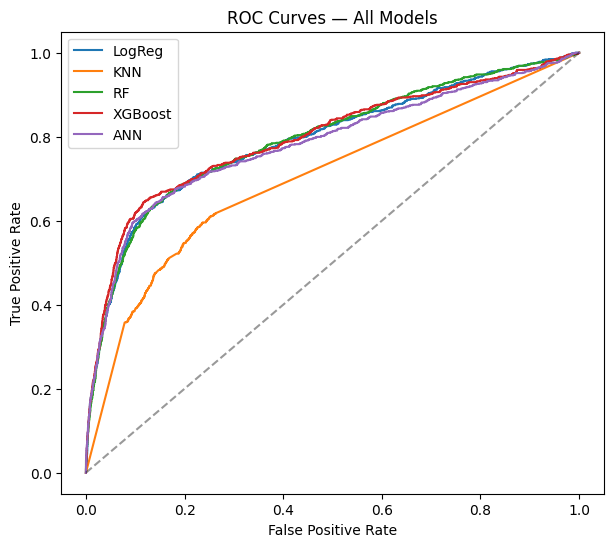

In [60]:
# ROC curves, all models on one plot
plt.figure(figsize=(7,6))
for name, model, is_keras in [
    ("LogReg", best_estimators["Linear_Model_Logistic_Regression"], False), 
    ("KNN", best_estimators["Distance_Based_KNN"], False),
    ("RF", best_estimators["Tree_Based_Random_Forest"], False), 
    ("XGBoost", best_estimators["Ensemble_Boosting_XGBoost"], False), 
    ("ANN", ann_model, True)
]:
    probs = model.predict(X_test_selected).flatten() if is_keras else model.predict_proba(X_test_selected)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend()
plt.show()

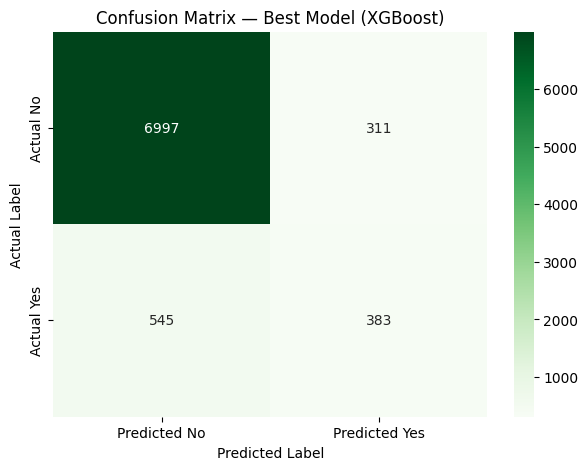

False negatives: 545 out of 928 actual subscribers


In [62]:
from sklearn.metrics import confusion_matrix

best_model = best_estimators["Ensemble_Boosting_XGBoost"]

# 2. Compute predictions and probabilities using the selected test features
preds = best_model.predict(X_test_selected)
probs = best_model.predict_proba(X_test_selected)[:, 1]

# 3. Generate and plot the Confusion Matrix
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title("Confusion Matrix — Best Model (XGBoost)")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

# 4. Look specifically at false negatives (Type II Errors)
fn_mask = (y_test == 1) & (preds == 0)
print(f"False negatives: {fn_mask.sum()} out of {(y_test==1).sum()} actual subscribers")

In [68]:
# Save the chosen model
import joblib

# Save the trained model
joblib.dump(best_model, "../models/term_deposit_model.pkl")

print("Model saved!")

Model saved!


Generating SHAP summary profile data...


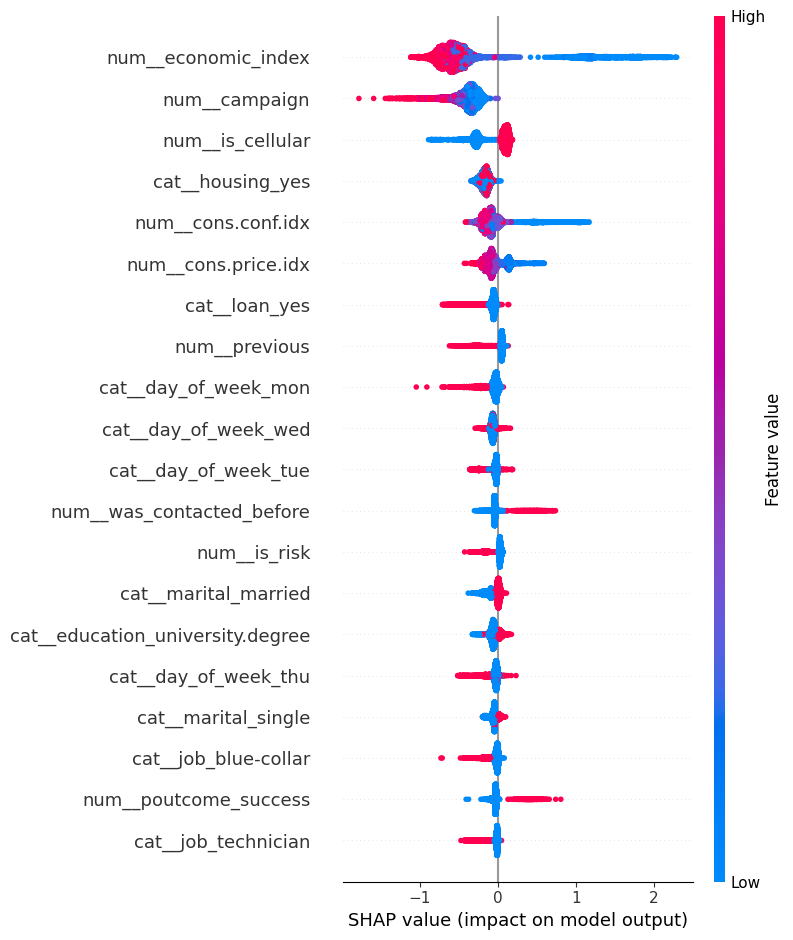

In [65]:
import shap

# Extract the chosen baseline ensemble booster from our best models map
chosen_tree_model = best_estimators["Ensemble_Boosting_XGBoost"]

# Initialize TreeExplainer engine matrix
explainer = shap.TreeExplainer(chosen_tree_model)
shap_values = explainer(X_test_selected)

# Render Global Feature Contribution Summary Diagram
print("Generating SHAP summary profile data...")
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_feature_names, show=False)